# 05. Кластеризация экономической сети

На этом этапе применяем Louvain к сети декабря 2024 и оцениваем полученное разбиение не только сетевой modularity, но и атрибутивными метриками Silhouette и Calinski-Harabasz. Затем исследуем влияние `resolution` и случайного seed.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx

from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score

## 1. Загрузка контрольной сети

Используем ребра, рассчитанные в `04_similarity_network`.

In [2]:
edges = pd.read_parquet(
    "../data/processed/edges_2024_12.parquet"
)

node_features = pd.read_parquet(
    "../data/processed/features_2024_12.parquet"
)

print("Рёбер:", len(edges))
print("Муниципалитетов:", len(node_features))

Рёбер: 13757
Муниципалитетов: 2103


## 2. Построение графа

Восстанавливаем взвешенный граф для community detection.

In [3]:
G = nx.Graph()

G.add_nodes_from(node_features["territory_id"])

for row in edges.itertuples(index=False):
    G.add_edge(
        int(row.source),
        int(row.target),
        weight=float(row.weight)
    )

print("Узлов:", G.number_of_nodes())
print("Рёбер:", G.number_of_edges())

Узлов: 2103
Рёбер: 13757


## 3. Louvain community detection

Louvain ищет группы узлов с относительно плотными внутренними связями. Параметр `resolution` управляет масштабом кластеризации.

In [4]:
communities = nx.community.louvain_communities(
    G,
    weight="weight",
    resolution=1.0,
    seed=42
)

print("Количество кластеров:", len(communities))

Количество кластеров: 17


## 4. Присвоение cluster labels

Преобразуем множество сообществ в удобный вектор меток для дальнейшей оценки по атрибутам.

In [5]:
labels = np.full(
    len(node_features),
    -1,
    dtype=int
)

territory_to_position = {
    territory_id: i
    for i, territory_id
    in enumerate(node_features["territory_id"])
}

for cluster_id, community in enumerate(communities):
    for territory_id in community:
        position = territory_to_position[territory_id]
        labels[position] = cluster_id

node_features["cluster"] = labels

node_features["cluster"].value_counts().sort_index()

cluster
0     127
1      88
2     126
3     166
4     154
5      69
6      15
7     235
8     126
9     145
10     74
11    155
12    161
13    144
14    106
15     62
16    150
Name: count, dtype: int64

In [6]:
print("Без кластера:", (labels == -1).sum())
print("Кластеров:", len(np.unique(labels)))

Без кластера: 0
Кластеров: 17


## 5. Сетевая оценка: modularity

Modularity оценивает, насколько ребра сосредоточены внутри найденных сообществ по сравнению со структурой случайного графа с теми же степенями.

In [7]:
modularity = nx.community.modularity(
    G,
    communities,
    weight="weight"
)

print("Modularity:", modularity)

Modularity: 0.814023681332355


## 6. Атрибутивные признаки для оценки

Для Silhouette и Calinski-Harabasz используем те же пять экономических долей, на которых строилась сеть.

In [8]:
model_features = [
    "food_share",
    "health_share",
    "marketplaces_share",
    "catering_share",
    "transport_share"
]

X = node_features[model_features].to_numpy()

## 7. Silhouette

Silhouette оценивает, насколько наблюдения ближе к своему кластеру, чем к соседним кластерам в пространстве экономических признаков.

In [9]:
silhouette = silhouette_score(
    X,
    labels,
    metric="euclidean"
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.1700955860982474


## 8. Calinski-Harabasz

Данный индекс сравнивает межкластерную и внутрикластерную дисперсию.

In [10]:
calinski = calinski_harabasz_score(
    X,
    labels
)

print("Calinski-Harabasz:", calinski)

Calinski-Harabasz: 852.564816920417


## 9. Профили кластеров

Помимо численных метрик строим средний экономический профиль каждого кластера для последующей интерпретации.

In [11]:
cluster_profile = (
    node_features
    .groupby("cluster")[model_features]
    .mean()
    .round(3)
)

cluster_profile

,food_share,health_share,marketplaces_share,catering_share,transport_share
cluster,,,,,
0,0.611,0.055,0.254,0.022,0.058
1,0.584,0.059,0.266,0.029,0.063
2,0.574,0.058,0.236,0.048,0.084
3,0.612,0.048,0.274,0.015,0.051
4,0.606,0.056,0.231,0.033,0.074
5,0.432,0.063,0.380,0.043,0.082
6,0.804,0.035,0.074,0.038,0.049
7,0.656,0.051,0.205,0.024,0.063
8,0.484,0.067,0.280,0.073,0.096


## 10. Визуальная проверка кластеров

Графики помогают увидеть, действительно ли сообщества отличаются по структуре расходов.

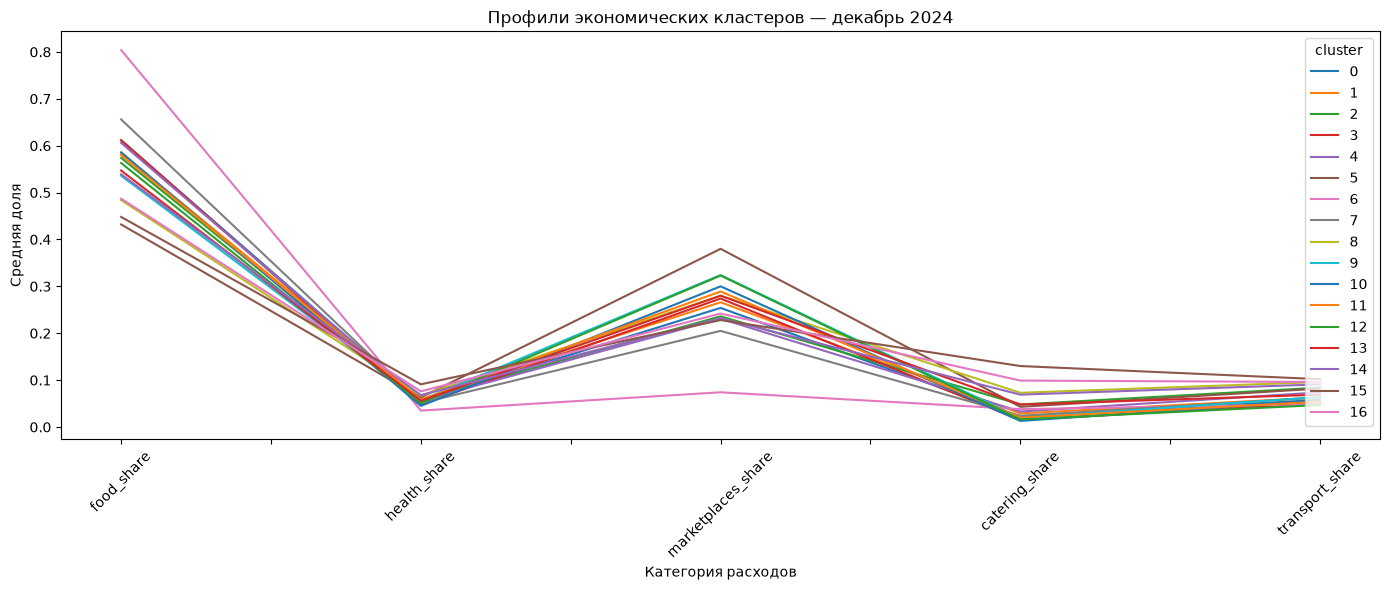

In [12]:
import matplotlib.pyplot as plt

cluster_profile.T.plot(
    figsize=(14, 6)
)

plt.xlabel("Категория расходов")
plt.ylabel("Средняя доля")
plt.title("Профили экономических кластеров — декабрь 2024")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Поиск подходящего `resolution`

Проверяем несколько значений масштаба Louvain и сравниваем число кластеров, modularity и атрибутивные показатели.

In [13]:
resolution_values = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]

results = []

for resolution in resolution_values:
    
    communities_test = nx.community.louvain_communities(
        G,
        weight="weight",
        resolution=resolution,
        seed=42
    )
    
    labels_test = np.full(
        len(node_features),
        -1,
        dtype=int
    )
    
    for cluster_id, community in enumerate(communities_test):
        for territory_id in community:
            position = territory_to_position[territory_id]
            labels_test[position] = cluster_id
    
    modularity_test = nx.community.modularity(
        G,
        communities_test,
        weight="weight"
    )
    
    silhouette_test = silhouette_score(
        X,
        labels_test,
        metric="euclidean"
    )
    
    calinski_test = calinski_harabasz_score(
        X,
        labels_test
    )
    
    results.append({
        "resolution": resolution,
        "n_clusters": len(communities_test),
        "modularity": modularity_test,
        "silhouette": silhouette_test,
        "calinski_harabasz": calinski_test
    })

results_df = pd.DataFrame(results)

results_df

,resolution,n_clusters,modularity,silhouette,calinski_harabasz
0,0.50,11,0.799149,0.178519,877.296293
1,0.75,15,0.811850,0.191845,892.947191
2,1.00,17,0.814024,0.170096,852.564817
3,1.25,20,0.814475,0.163593,879.100115
4,1.50,19,0.813972,0.178424,914.598833
5,2.00,29,0.799360,0.114000,623.715928


## 12. Проверка устойчивости к seed

Одно разбиение с одним seed недостаточно для оценки устойчивости community detection, поэтому дополнительно сравниваем решения по ARI.

In [14]:
from sklearn.metrics import adjusted_rand_score

## 13. Сравнение кандидатов

Фокусируемся на нескольких разумных значениях `resolution`, чтобы увидеть, насколько результат зависит от масштаба кластеризации.

In [15]:
candidate_resolutions = [0.75, 1.0, 1.5]
seeds = [1, 2, 3, 4, 5]

In [16]:
candidate_resolutions = [0.75, 1.0, 1.5]
seeds = [1, 2, 3, 4, 5]

stability_results = []

for resolution in candidate_resolutions:
    
    all_labels = []
    
    for seed in seeds:
        
        communities_seed = nx.community.louvain_communities(
            G,
            weight="weight",
            resolution=resolution,
            seed=seed
        )
        
        labels_seed = np.full(
            len(node_features),
            -1,
            dtype=int
        )
        
        for cluster_id, community in enumerate(communities_seed):
            for territory_id in community:
                position = territory_to_position[territory_id]
                labels_seed[position] = cluster_id
        
        all_labels.append(labels_seed)
    
    ari_values = []
    
    for i in range(len(all_labels)):
        for j in range(i + 1, len(all_labels)):
            ari = adjusted_rand_score(
                all_labels[i],
                all_labels[j]
            )
            ari_values.append(ari)
    
    stability_results.append({
        "resolution": resolution,
        "mean_ARI": np.mean(ari_values),
        "min_ARI": np.min(ari_values),
        "max_ARI": np.max(ari_values)
    })

stability_df = pd.DataFrame(stability_results)

stability_df

,resolution,mean_ARI,min_ARI,max_ARI
0,0.75,0.645700,0.560775,0.758369
1,1.00,0.602832,0.522163,0.697080
2,1.50,0.681941,0.602363,0.764437
